# Progetto del corso - Introduzione al Pensiero Computazionale e alla Data Science

**Dataset scelto:** Employee Attrition
**Obiettivo:** previsione dell'abbandono dei dipendenti (`Attrition`)

**Team:** [Paolo Magnanelli - 1231652], [Asia Milan - matricola].

---
# Fase 1 - Setup del progetto

In questa cella importiamo le librerie che useremo in tutto il notebook.

- `pandas`, `numpy` per la gestione dei dati
- `matplotlib`, `seaborn` per le visualizzazioni
- `scikit-learn` per modellazione e metriche

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    classification_report,
    precision_score,
    recall_score,
    f1_score,
)

In [2]:
df = pd.read_csv("Employee_Attrition.csv")
df.head()

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2


---
# Fase 2 - Descrizione e comprensione del dataset

Lo schema che useremo per ogni domanda è:

1. esposizione della domanda/ipotesi;
2. recupero e visualizzazione dell'informazione;
3. risposta/considerazione.

**Iniziamo con una panoramica**: dimensioni, tipi di variabili e presenza di
valori mancanti.

In [ ]:
print("Numero di righe:", df.shape[0])
print("Numero di colonne:", df.shape[1])
df.info()

Numero di righe: 1470
Numero di colonne: 35
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 35 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   Age                       1470 non-null   int64 
 1   Attrition                 1470 non-null   object
 2   BusinessTravel            1470 non-null   object
 3   DailyRate                 1470 non-null   int64 
 4   Department                1470 non-null   object
 5   DistanceFromHome          1470 non-null   int64 
 6   Education                 1470 non-null   int64 
 7   EducationField            1470 non-null   object
 8   EmployeeCount             1470 non-null   int64 
 9   EmployeeNumber            1470 non-null   int64 
 10  EnvironmentSatisfaction   1470 non-null   int64 
 11  Gender                    1470 non-null   object
 12  HourlyRate                1470 non-null   int64 
 13  JobInvolvement            1470 non

In [3]:
df.describe()

,Age,DailyRate,DistanceFromHome,Education,EmployeeCount,EmployeeNumber,EnvironmentSatisfaction,HourlyRate,JobInvolvement,JobLevel,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
count,1470.000000,1470.000000,1470.000000,1470.000000,1470.0,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,...,1470.000000,1470.0,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000
mean,36.923810,802.485714,9.192517,2.912925,1.0,1024.865306,2.721769,65.891156,2.729932,2.063946,...,2.712245,80.0,0.793878,11.279592,2.799320,2.761224,7.008163,4.229252,2.187755,4.123129
std,9.135373,403.509100,8.106864,1.024165,0.0,602.024335,1.093082,20.329428,0.711561,1.106940,...,1.081209,0.0,0.852077,7.780782,1.289271,0.706476,6.126525,3.623137,3.222430,3.568136
min,18.000000,102.000000,1.000000,1.000000,1.0,1.000000,1.000000,30.000000,1.000000,1.000000,...,1.000000,80.0,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000
25%,30.000000,465.000000,2.000000,2.000000,1.0,491.250000,2.000000,48.000000,2.000000,1.000000,...,2.000000,80.0,0.000000,6.000000,2.000000,2.000000,3.000000,2.000000,0.000000,2.000000
50%,36.000000,802.000000,7.000000,3.000000,1.0,1020.500000,3.000000,66.000000,3.000000,2.000000,...,3.000000,80.0,1.000000,10.000000,3.000000,3.000000,5.000000,3.000000,1.000000,3.000000
75%,43.000000,1157.000000,14.000000,4.000000,1.0,1555.750000,4.000000,83.750000,3.000000,3.000000,...,4.000000,80.0,1.000000,15.000000,3.000000,3.000000,9.000000,7.000000,3.000000,7.000000
max,60.000000,1499.000000,29.000000,5.000000,1.0,2068.000000,4.000000,100.000000,4.000000,5.000000,...,4.000000,80.0,3.000000,40.000000,6.000000,4.000000,40.000000,18.000000,15.000000,17.000000


**Considerazioni:** il dataset contiene 1470 osservazioni (dipendenti) e 35
colonne. Non sono presenti tipi di dato anomali a prima vista: la maggior parte
delle variabili è numerica (int64), mentre alcune sono categoriche (stringhe).
Procediamo a verificare i valori mancanti.

### Domanda 1 - Ci sono valori mancanti?

In [4]:
df.isna().sum()

,0
Age,0
Attrition,0
BusinessTravel,0
DailyRate,0
Department,0
DistanceFromHome,0
Education,0
EducationField,0
EmployeeCount,0
EmployeeNumber,0


**Considerazioni:** non risultano valori mancanti (`NaN`) in nessuna colonna.


### Domanda 2 - Quali sono le variabili numeriche e quali categoriche?


In [5]:
print("Variabili nuemriche e catgoriche:")
df.dtypes.value_counts()

Variabili nuemriche e catgoriche:


,count
int64,26
object,9


In [13]:
numeriche = df.select_dtypes(include="number").columns
categoriche = df.select_dtypes(exclude="number").columns

print("Variabili numeriche:")
for col in numeriche:
    print("-", col)

print("\nVariabili categoriche:")
for col in categoriche:
    print("-", col)

Variabili numeriche:
- Age
- DailyRate
- DistanceFromHome
- Education
- EmployeeCount
- EmployeeNumber
- EnvironmentSatisfaction
- HourlyRate
- JobInvolvement
- JobLevel
- JobSatisfaction
- MonthlyIncome
- MonthlyRate
- NumCompaniesWorked
- PercentSalaryHike
- PerformanceRating
- RelationshipSatisfaction
- StandardHours
- StockOptionLevel
- TotalWorkingYears
- TrainingTimesLastYear
- WorkLifeBalance
- YearsAtCompany
- YearsInCurrentRole
- YearsSinceLastPromotion
- YearsWithCurrManager

Variabili categoriche:
- Attrition
- BusinessTravel
- Department
- EducationField
- Gender
- JobRole
- MaritalStatus
- Over18
- OverTime


**Considerazioni:** ci sono 26 variabili numeriche e 9 categoriche
(incluso il target `Attrition`). Tra le variabili categoriche troviamo
informazioni come `Department`, `JobRole`, `MaritalStatus`, `OverTime`, ecc.

### Domanda 3 - Esistono colonne che, anche se numeriche, contengono un solo valore?

Una colonna che ha sempre lo stesso valore non porta nessuna informazione utile
per un modello predittivo: è quindi importante identificarla.

In [14]:
nunique = df.nunique().sort_values()
nunique.head(10)

,0
EmployeeCount,1
Over18,1
StandardHours,1
Attrition,2
OverTime,2
PerformanceRating,2
Gender,2
BusinessTravel,3
Department,3
MaritalStatus,3


In [49]:
constant_cols = [col for col in df.columns if df[col].nunique() == 1]
print("Variabili costanti:", constant_cols)

Variabili costanti: ['EmployeeCount', 'Over18', 'StandardHours']


**Considerzioni**: Emerge che alcune variabili presentano un solo valore (come `EmployeeCount`, `Over18` e `StandardHours`) e quindi non forniscono informazioni utili per l’analisi.

Altre variabili hanno solo poche categorie (ad esempio `Attrition`, `OverTime`, `Gender`), sono quindi facilmente interpretabili ma con una variabilità bassa.

Infine, alcune variabili categoriali presentano più livelli (come `BusinessTravel`, `Department` e `MaritalStatus`), mostrano diversità e potenziale informativo.


### Domanda 4 -  Qual è la distribuzione della variabile target `Attrition`? Il dataset è bilanciato o sbilanciato?


In [20]:
attrition_counts = df["Attrition"].value_counts()
attrition_per = df["Attrition"].value_counts(normalize=True) * 100

print(attrition_counts)
print()
print(attrition_per.round(2)) #solo due decimali

Attrition
No     1233
Yes     237
Name: count, dtype: int64

Attrition
No     83.88
Yes    16.12
Name: proportion, dtype: float64


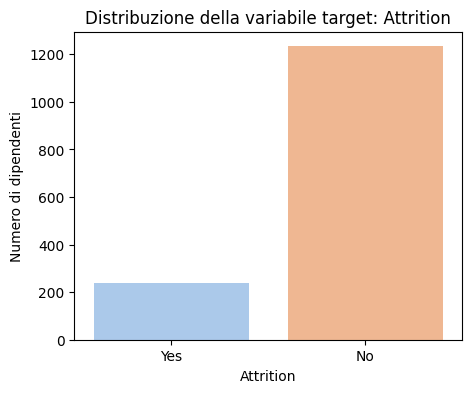

In [21]:
plt.figure(figsize=(5, 4))
sns.countplot(data=df,
              x="Attrition",
              hue="Attrition",
              palette="pastel",
)
plt.xlabel("Attrition")
plt.ylabel("Numero di dipendenti")

plt.title("Distribuzione della variabile target: Attrition")
plt.show()

**Considerazioni:** la classe `Yes` (dipendenti che hanno lasciato
l'azienda) rappresenta circa il 16% del dataset, contro l'84% della classe
`No`. Si tratta quindi di un dataset **sbilanciato (class imbalance)**: questo
sarà importante in fase 4/5, perché un modello che predice sempre `No`
otterrebbe un'accuracy "ingannevole" di circa l'84% senza essere effettivamente
utile.

### Domanda 5 - Quali sono le statistiche descrittive principali delle variabili numeriche più rilevanti?


In [22]:
df[["Age", "MonthlyIncome", "DistanceFromHome", "TotalWorkingYears",
    "YearsAtCompany", "JobSatisfaction"]].describe().T

,count,mean,std,min,25%,50%,75%,max
Age,1470.0,36.923810,9.135373,18.0,30.0,36.0,43.0,60.0
MonthlyIncome,1470.0,6502.931293,4707.956783,1009.0,2911.0,4919.0,8379.0,19999.0
DistanceFromHome,1470.0,9.192517,8.106864,1.0,2.0,7.0,14.0,29.0
TotalWorkingYears,1470.0,11.279592,7.780782,0.0,6.0,10.0,15.0,40.0
YearsAtCompany,1470.0,7.008163,6.126525,0.0,3.0,5.0,9.0,40.0
JobSatisfaction,1470.0,2.728571,1.102846,1.0,2.0,3.0,4.0,4.0


**Considerazioni:** l'età media dei dipendenti è di circa 37 anni (min 18,
max 60). Il reddito mensile (`MonthlyIncome`) è molto variabile (da circa 1000 a
quasi 20000), con una deviazione standard ampia che evidenzia la presenza di
ruoli/livelli molto diversi tra loro.

`YearsAtCompany` ha una mediana inferiore
alla media. Questo indica una distribuzione asimmetrica e con outliers che influenzano la media, ovvero alcuni dipendenti di
lunga data.

### Domanda 6 - Sono presenti outlier evidenti nelle variabili numeriche rilevanti?


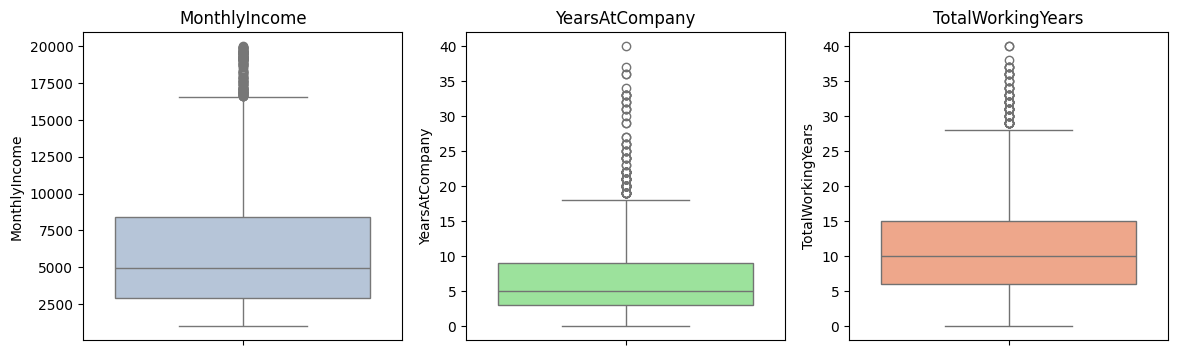

In [33]:
# crea una figura con 1 riga e 3 grafici (colonne)
# figsize controlla la dimensione del grafico (larghezza 14, altezza 4)
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

sns.boxplot(data=df, y="MonthlyIncome", ax=axes[0], color="lightsteelblue")
# ax=axes[0] -> primo spazio del grafico (a sinistra)
axes[0].set_title("MonthlyIncome")

sns.boxplot(data=df, y="YearsAtCompany", ax=axes[1], color="lightgreen")
axes[1].set_title("YearsAtCompany")

sns.boxplot(data=df, y="TotalWorkingYears", ax=axes[2], color="lightsalmon")
axes[2].set_title("TotalWorkingYears")

plt.show()

**Considerazioni**: usiamo dei boxplot per individuare visivamente valori estremi.

Tutte e tre le variabili mostrano alcuni outliers. Tuttavia questi valori (es. dipendenti con molti anni di servizio o stipendi alti) rappresentano situazioni realistiche e non errori di inserimento dati. Si tratta probabilmente di dipendenti senior/dirigenziali. **Ne teniamo conto nell'interpretazione dei risultati**.

### Domanda 7 - Quali sono le categorie più frequenti nelle variabili categoriche principali?


In [44]:
for col in ["Department", "JobRole", "MaritalStatus", "BusinessTravel", "OverTime"]:
    print(f"--- {col} ---")
    print(df[col].value_counts(normalize=True).round(4) * 100)
    print()

--- Department ---
Department
Research & Development    65.37
Sales                     30.34
Human Resources            4.29
Name: proportion, dtype: float64

--- JobRole ---
JobRole
Sales Executive              22.18
Research Scientist           19.86
Laboratory Technician        17.62
Manufacturing Director        9.86
Healthcare Representative     8.91
Manager                       6.94
Sales Representative          5.65
Research Director             5.44
Human Resources               3.54
Name: proportion, dtype: float64

--- MaritalStatus ---
MaritalStatus
Married     45.78
Single      31.97
Divorced    22.24
Name: proportion, dtype: float64

--- BusinessTravel ---
BusinessTravel
Travel_Rarely        70.95
Travel_Frequently    18.84
Non-Travel           10.20
Name: proportion, dtype: float64

--- OverTime ---
OverTime
No     71.7
Yes    28.3
Name: proportion, dtype: float64



**Considerazioni**: la maggior parte dei dipendenti:
* lavora nel dipartimento "Research & Development" (circa 65%),
* è sposata (circa 46%),
* viaggia raramente per lavoro ("Travel_Rarely", circa 71%).

Circa il 28% dei dipendenti fa straordinari (`OverTime` = Yes). **Questa variabile sarà particolarmente interessante da analizzare in fase 3, perché spesso è associata all'`attrition`**.

# Domande 8 - Alcune features numeriche sono fortemente correlate tra loro?

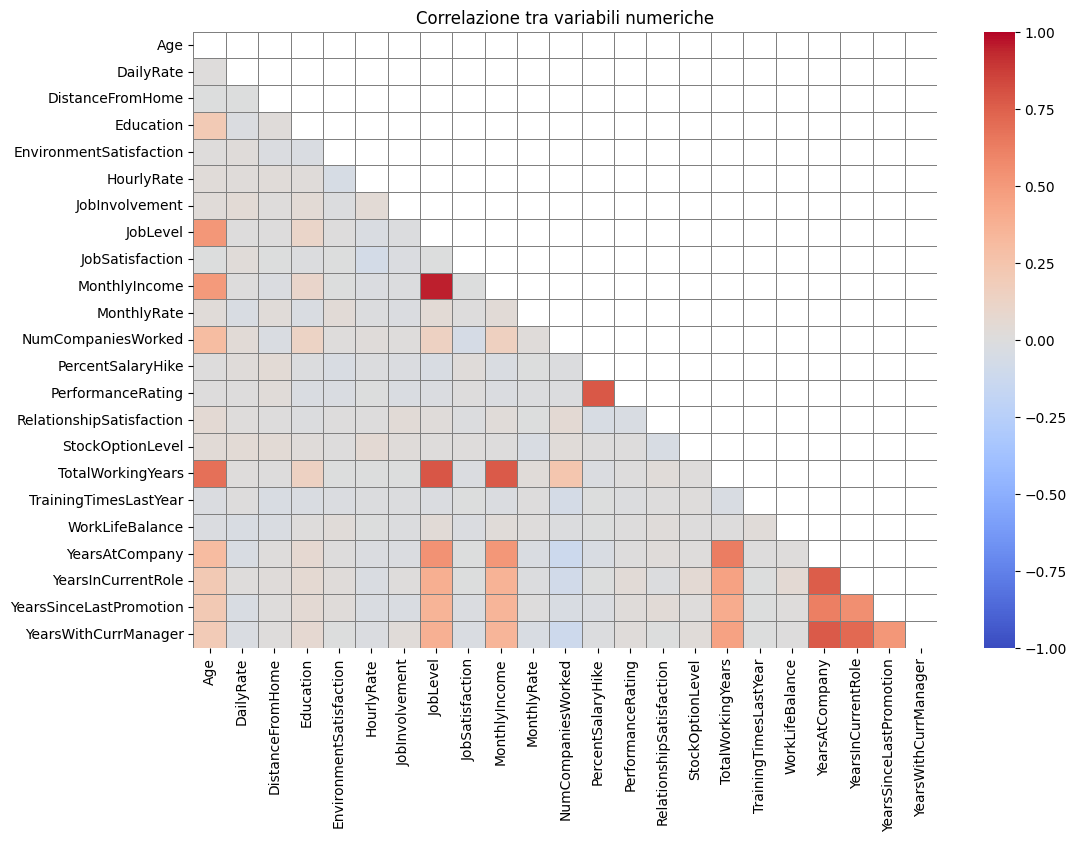

In [73]:
variabili = [col for col in df.select_dtypes(include="number")
             if col not in constant_cols + ["EmployeeNumber"]]

corr = df[variabili].corr()

plt.figure(figsize=(12, 8))
mask = np.triu(np.ones_like(corr, dtype=bool))

sns.heatmap(
    corr,
    mask= mask,
    cmap= "coolwarm",
    vmin= -1,
    vmax= 1,
    center= 0,
    linewidths= 0.7,        #linee più spesse
    linecolor= "gray"      #colore delle linee
)

plt.title("Correlazione tra variabili numeriche")
plt.show()


In [72]:
lista= []


for col1 in corr.columns:
    for col2 in corr.columns:
        if col1 < col2:
            valore= corr.loc[col1, col2]
            lista.append([col1, col2, abs(valore)])


tabella= pd.DataFrame(lista, columns=["Variabile 1", "Variabile 2", "Correlazione"])
tabella= tabella.sort_values(by="Correlazione", ascending=False)

top10= tabella.head(10)
print(top10)

            Variabile 1              Variabile 2  Correlazione
134            JobLevel            MonthlyIncome      0.950300
141            JobLevel        TotalWorkingYears      0.782208
198   PercentSalaryHike        PerformanceRating      0.773550
168       MonthlyIncome        TotalWorkingYears      0.772893
249      YearsAtCompany     YearsWithCurrManager      0.769212
247      YearsAtCompany       YearsInCurrentRole      0.758754
251  YearsInCurrentRole     YearsWithCurrManager      0.714365
15                  Age        TotalWorkingYears      0.680381
234   TotalWorkingYears           YearsAtCompany      0.628133
248      YearsAtCompany  YearsSinceLastPromotion      0.618409


**Considerazioni**: alcune variabili numeriche sono fortemente correlate tra loro, in particolare c'è una correlazione molto elevata tra `MonthlyIncome` e `JobLevel` (circa 0.95), mostrando, come si poteva immagianre, che stipendi più alti sono correlati a lavori più elevati.

Anche `TotalWorkingYears` è fortemente correlata con `JobLevel` e `MonthlyIncome` (circa 0.78), eveidenziando che l'esperienza lavorativa totale influisce sia sul ruolo che sul reddito.

Le variabili legate alla permanenza (`YearsAtCompany`, `YearsInCurrentRole`, `YearsWithCurrManager`) mostrano anch’esse correlazioni elevate tra loro (tra 0.71 e 0.77), indicando una forte relazione tra anzianità e stabilità lavorativa.

Un'ulteriore correlazione significativa è tra `PercentSalaryHike` e `PerformanceRating` (circa 0.77), quindi le performance lavorative influenzano gli aumenti salariali.

Infine, `Age` è moderatamente correlata con `TotalWorkingYears`(circa 0.68), coerentemente collegato al fatto che i lavoratori più anziani tendono ad avere una maggiore esperienza.


### Conclusioni della fase 2
1. Il dataset contiene 1470 osservazioni e 35 variabili:
  - 26 numeriche
  - 9 categoriche  

2. Non sono presenti valori mancanti, quindi i dati risultano completi.

3. La variabile target `Attrition` è sbilanciata come ci aspettavamo da un dataset HR che tratta di tale tema:
  - circa 84% dipendenti che restano  
  - circa 16% che lasciano  

4. Sono presenti alcune variabili non informative (costanti), come:
  - `EmployeeCount`
  - `Over18`
  - `StandardHours`

5. Le variabili numeriche mostrano:
  - elevata variabilità → `MonthlyIncome`
  - presenza di outlier, ma realistici → dipendenti senior

6. Le variabili categoriche evidenziano che:
  - la maggior parte lavora in "Research & Development"
  - molti sono sposati
  - circa il 28% fa straordinari  

7. L’analisi delle correlazioni mostra:
  - forte relazione tra reddito e livello del ruolo
  - legame tra esperienza, reddito e posizione lavorativa
  - alta correlazione tra variabili legate agli anni in azienda  



---
# Fase 3 - Analisi esplorativa e visualizzazione

**Obiettivo:** capire (e comunicare) le relazioni tra le feature, in particolare
rispetto al target `Attrition`.

Per facilitare i confronti, creiamo una versione numerica del target
(`Attrition_num`): `1` = "Yes" (il dipendente ha lasciato l'azienda), `0` = "No".

In [ ]:
df["Attrition_num"] = (df["Attrition"] == "Yes").astype(int)
df[["Attrition", "Attrition_num"]].head()

,Attrition,Attrition_num
0,Yes,1
1,No,0
2,Yes,1
3,No,0
4,No,0


### Domanda 1 - Bla Bla?

### Domanda 2 - Bla Bla?

### Domanda 3 - Bla Bla?

### Domanda 4 - Bla Bla?

---
# Fase 4 - Modellazione

---
# Fase 5 - Valutazione e interpretazione dei risultati

---
# Conclusioni e possibili approfondimenti